# 🚀 Preprocessing Pipeline — HARMONIC & DASIG

**PhD Project:** Collaboration Humain-Robot : Apprentissage incrémental et adaptation comportementale  
**Notebook:** `02_preprocessing_pipeline.ipynb`  

This self-contained Colab notebook:
1. Downloads both datasets (HARMONIC + DASIG) with resume support
2. Defines all preprocessing modules inline (no local package install needed)
3. Runs the full HARMONIC preprocessing pipeline (alignment + EMG/gaze/IMU filtering)
4. Runs the full DASIG preprocessing pipeline (MIMU filtering + feature extraction)
5. Generates reproducible train/val/test splits
6. Saves everything to Google Drive for persistence

---

## 0. Environment Setup

In [1]:
# Mount Google Drive for persistent storage
from google.colab import drive
drive.mount('/content/drive')

# Create project directories
import os
PROJECT_ROOT = '/content/drive/MyDrive/thesis_project'
DATA_RAW     = '/content/data'           # Local fast storage for raw data
DATA_PROC    = f'{PROJECT_ROOT}/data/processed'  # Processed → Drive
SPLITS_DIR   = f'{PROJECT_ROOT}/configs/splits'

for d in [DATA_RAW, DATA_PROC, SPLITS_DIR,
          f'{DATA_PROC}/harmonic', f'{DATA_PROC}/dasig']:
    os.makedirs(d, exist_ok=True)

print(f'Project root : {PROJECT_ROOT}')
print(f'Raw data     : {DATA_RAW}')
print(f'Processed    : {DATA_PROC}')

Mounted at /content/drive
Project root : /content/drive/MyDrive/thesis_project
Raw data     : /content/data
Processed    : /content/drive/MyDrive/thesis_project/data/processed


In [2]:
# Install any missing packages
!pip install -q pyarrow fastparquet gdown hdbscan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 37.5 MB/s eta 0:00:00a 0:00:01


In [3]:
# Core imports
import json
import logging
import time
import warnings
from dataclasses import dataclass, field
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal as scipy_signal

warnings.filterwarnings('ignore', category=FutureWarning)
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
logger = logging.getLogger('pipeline')

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
print('Imports OK')

Imports OK


---
## 1. Dataset Download (Resumable)

In [6]:
import subprocess, hashlib, tarfile, zipfile, urllib.request

# ---- HARMONIC (text-only, ~4.25 GB from Google Drive) ----
HARMONIC_GDRIVE_ID = '1G4_fGdH0fB_8JCHj4vCEfcaej-oXs7M4'
HARMONIC_TAR       = f'{DATA_RAW}/harmonic_1.0.0_text.tar.gz'
HARMONIC_DIR       = f'{DATA_RAW}/harmonic'

if not os.path.isdir(HARMONIC_DIR) or len(os.listdir(HARMONIC_DIR)) == 0:
    if not os.path.isfile(HARMONIC_TAR):
        print('Downloading HARMONIC (text-only) ~4.25 GB ...')
        !gdown --id {HARMONIC_GDRIVE_ID} -O {HARMONIC_TAR} 
    print('Extracting HARMONIC ...')
    os.makedirs(HARMONIC_DIR, exist_ok=True)
    with tarfile.open(HARMONIC_TAR, 'r:gz') as t:
        t.extractall(HARMONIC_DIR)
    print('HARMONIC extraction complete.')
else:
    print(f'HARMONIC already present at {HARMONIC_DIR}')

# ---- DASIG (from Zenodo, ~1.8 GB) ----
DASIG_ZENODO_URL = 'https://zenodo.org/records/17660014/files/DASIG.zip'
DASIG_ZIP        = f'{DATA_RAW}/DASIG.zip'
DASIG_DIR        = f'{DATA_RAW}/dasig'

if not os.path.isdir(DASIG_DIR) or len(os.listdir(DASIG_DIR)) == 0:
    if not os.path.isfile(DASIG_ZIP):
        print('Downloading DASIG from Zenodo ...')
        !wget -c -q --show-progress -O {DASIG_ZIP} "{DASIG_ZENODO_URL}"
    print('Extracting DASIG ...')
    os.makedirs(DASIG_DIR, exist_ok=True)
    with zipfile.ZipFile(DASIG_ZIP, 'r') as z:
        z.extractall(DASIG_DIR)
    print('DASIG extraction complete.')
else:
    print(f'DASIG already present at {DASIG_DIR}')

# Quick verification
harmonic_contents = sorted(os.listdir(HARMONIC_DIR))[:5]
dasig_contents = sorted(os.listdir(DASIG_DIR))[:5]
print(f'\nHARMONIC root contents: {harmonic_contents}')
print(f'DASIG root contents:    {dasig_contents}')

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1G4_fGdH0fB_8JCHj4vCEfcaej-oXs7M4
From (redirected): https://drive.google.com/uc?id=1G4_fGdH0fB_8JCHj4vCEfcaej-oXs7M4&confirm=t&uuid=72e07907-d35f-493b-8de5-59127cc4cd72
To: /content/data/harmonic_1.0.0_text.tar.gz
100% 4.57G/4.57G [00:47<00:00, 95.7MB/s]
Extracting HARMONIC ...


/tmp/ipython-input-207150144.py:15: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  t.extractall(HARMONIC_DIR)


HARMONIC extraction complete.
/content/data/DASIG 100%[===================>]   3.24G  12.8MB/s    in 4m 20s  
Extracting DASIG ...
DASIG extraction complete.

HARMONIC root contents: ['harmonic_0.5.0']
DASIG root contents:    ['DASIG']


---
## 2. Module Definitions

All preprocessing code is defined inline so this notebook is fully self-contained on Colab.

### 2.1 HARMONIC Loader

In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# HARMONIC Dataset Loader
# ═══════════════════════════════════════════════════════════════════════════

HARMONIC_MODALITIES = [
    'ada_joy', 'assistance_info', 'gaze_positions', 'input_info',
    'joint_positions', 'myo_emg', 'myo_imu', 'myo_ori',
    'pose_left_face_2d', 'pose_left_hand_left_2d',
    'pose_left_hand_right_2d', 'pose_left_pose_2d',
    'pose_right_face_2d', 'pose_right_hand_left_2d',
    'pose_right_hand_right_2d', 'pose_right_pose_2d',
    'pupil_cal_eye0', 'pupil_cal_eye1', 'pupil_eye0', 'pupil_eye1',
    'robot_position', 'world_cal_positions',
]

CORE_MODALITIES = [
    'ada_joy', 'gaze_positions', 'joint_positions', 'robot_position',
    'myo_emg', 'myo_imu', 'assistance_info', 'input_info',
]


@dataclass
class TrialInfo:
    participant: str
    trial_type: str
    trial_id: str
    text_data_dir: Path
    n_csv_files: int = 0
    available_modalities: list = field(default_factory=list)
    has_emg: bool = False

    @property
    def trial_key(self) -> str:
        return f'{self.participant}/{self.trial_type}/{self.trial_id}'


@dataclass
class TrialData:
    info: TrialInfo
    modalities: dict = field(default_factory=dict)

    def has(self, modality: str) -> bool:
        return modality in self.modalities and len(self.modalities[modality]) > 0


def discover_participants(harmonic_root):
    harmonic_root = Path(harmonic_root)
    versioned = list(harmonic_root.glob('harmonic_*'))
    base = versioned[0] if versioned else harmonic_root
    parts = sorted(d.name for d in base.iterdir() if d.is_dir() and d.name.startswith('p'))
    logger.info(f'Found {len(parts)} participants in {base}')
    return parts


def discover_trials(harmonic_root, trial_type='run', participants=None,
                    require_modalities=None, min_csv_size_kb=0.5):
    harmonic_root = Path(harmonic_root)
    versioned = list(harmonic_root.glob('harmonic_*'))
    base = versioned[0] if versioned else harmonic_root

    if participants is None:
        participants = discover_participants(harmonic_root)

    trials = []
    types_to_scan = ['run', 'check'] if trial_type == 'all' else [trial_type]

    for pid in participants:
        for ttype in types_to_scan:
            type_dir = base / pid / ttype
            if not type_dir.exists():
                continue
            for trial_dir in sorted(type_dir.iterdir()):
                if not trial_dir.is_dir():
                    continue
                td = trial_dir / 'text_data'
                if not td.exists():
                    continue
                csv_files = sorted(td.glob('*.csv'))
                available = [f.stem for f in csv_files
                            if f.stat().st_size >= min_csv_size_kb * 1024]

                info = TrialInfo(
                    participant=pid, trial_type=ttype, trial_id=trial_dir.name,
                    text_data_dir=td, n_csv_files=len(csv_files),
                    available_modalities=available, has_emg='myo_emg' in available,
                )
                if require_modalities:
                    if all(m in available for m in require_modalities):
                        trials.append(info)
                else:
                    trials.append(info)

    logger.info(f'Discovered {len(trials)} {trial_type} trials '
                f'across {len(set(t.participant for t in trials))} participants')
    return trials


def load_trial(trial, modalities=None, max_rows=None):
    td = trial.text_data_dir
    target = modalities or trial.available_modalities
    loaded = {}
    for mod in target:
        csv_path = td / f'{mod}.csv'
        if not csv_path.exists():
            continue
        try:
            loaded[mod] = pd.read_csv(csv_path, nrows=max_rows)
        except Exception as e:
            logger.warning(f'Error loading {mod} for {trial.trial_key}: {e}')
            loaded[mod] = pd.DataFrame()
    return TrialData(info=trial, modalities=loaded)


print('\u2705 HARMONIC loader defined')

✅ HARMONIC loader defined


### 2.2 HARMONIC Signal Preprocessing

In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# HARMONIC Signal Preprocessing
# ═══════════════════════════════════════════════════════════════════════════

@dataclass
class PreprocessConfig:
    target_rate_hz: float = 50.0
    emg_bandpass_low: float = 20.0
    emg_bandpass_high: float = 450.0
    emg_notch_freq: float = 50.0
    emg_rms_window_ms: float = 100.0
    emg_original_rate_hz: float = 50.0
    gaze_confidence_threshold: float = 0.5
    gaze_interpolation_method: str = 'linear'
    gaze_smoothing_window: int = 5
    normalization_method: str = 'zscore'
    filter_order: int = 4


def align_timestamps(modalities, target_rate_hz=50.0, timestamp_col='timestamp'):
    """Resample all modalities to a common time grid."""
    t_starts, t_ends = [], []
    for name, df in modalities.items():
        if df.empty or timestamp_col not in df.columns:
            continue
        ts = df[timestamp_col].values
        t_starts.append(ts.min()); t_ends.append(ts.max())

    if not t_starts:
        return modalities

    t_start, t_end = max(t_starts), min(t_ends)
    if t_end <= t_start:
        return modalities

    duration = t_end - t_start
    n_samples = int(duration * target_rate_hz) + 1
    common_time = np.linspace(t_start, t_end, n_samples)
    time_s = common_time - t_start

    resampled = {}
    exclude = {timestamp_col, 'world_index', 'world_index_corrected'}

    for name, df in modalities.items():
        if df.empty or timestamp_col not in df.columns:
            resampled[name] = df; continue
        df_sorted = df.sort_values(timestamp_col)
        ts_orig = df_sorted[timestamp_col].values
        data_cols = [c for c in df_sorted.columns
                     if c not in exclude and pd.api.types.is_numeric_dtype(df_sorted[c])]
        if not data_cols:
            resampled[name] = df; continue

        new_data = {'time_s': time_s}
        for col in data_cols:
            vals = df_sorted[col].values.astype(float)
            mask = ~np.isnan(vals)
            new_data[col] = np.interp(common_time, ts_orig[mask], vals[mask]) if mask.sum() >= 2 else np.full(n_samples, np.nan)
        resampled[name] = pd.DataFrame(new_data)

    return resampled


def _rms_envelope(sig, win):
    if win <= 1: return np.abs(sig)
    sq = sig ** 2
    return np.sqrt(np.maximum(np.convolve(sq, np.ones(win)/win, 'same'), 0))


def preprocess_emg(emg_df, config=None):
    if config is None: config = PreprocessConfig()
    if emg_df.empty: return emg_df
    emg_cols = [c for c in emg_df.columns if c.startswith('emg')]
    if not emg_cols: return emg_df
    result = emg_df.copy()
    fs = config.emg_original_rate_hz
    for col in emg_cols:
        raw = result[col].values.astype(float)
        if np.all(raw == 0) or np.all(np.isnan(raw)): continue
        nyquist = fs / 2.0
        if config.emg_bandpass_high < nyquist and config.emg_bandpass_low < nyquist:
            b, a = scipy_signal.butter(config.filter_order,
                    [config.emg_bandpass_low/nyquist, config.emg_bandpass_high/nyquist], 'band')
            filt = scipy_signal.filtfilt(b, a, raw)
        elif config.emg_bandpass_low < nyquist:
            b, a = scipy_signal.butter(config.filter_order, config.emg_bandpass_low/nyquist, 'high')
            filt = scipy_signal.filtfilt(b, a, raw)
        else:
            filt = raw - np.nanmean(raw)
        rect = np.abs(filt)
        win_s = max(1, int(config.emg_rms_window_ms / 1000.0 * fs))
        env = _rms_envelope(rect, win_s)
        if config.normalization_method == 'zscore':
            m, s = np.nanmean(env), np.nanstd(env)
            env = (env - m) / s if s > 1e-8 else env - m
        result[col] = env
    return result


def preprocess_gaze(gaze_df, config=None):
    if config is None: config = PreprocessConfig()
    if gaze_df.empty: return gaze_df
    result = gaze_df.copy()
    if 'confidence' in result.columns:
        low = result['confidence'] < config.gaze_confidence_threshold
        for col in ['norm_pos_x', 'norm_pos_y']:
            if col in result.columns:
                result.loc[low, col] = np.nan
    for col in ['norm_pos_x', 'norm_pos_y']:
        if col in result.columns:
            result[col] = result[col].interpolate(method='linear', limit_direction='both')
            if config.gaze_smoothing_window > 1:
                result[col] = result[col].rolling(config.gaze_smoothing_window, center=True, min_periods=1).mean()
    return result


def preprocess_imu(imu_df, config=None):
    if config is None: config = PreprocessConfig()
    if imu_df.empty: return imu_df
    result = imu_df.copy()
    fs = config.emg_original_rate_hz
    cutoff, nyq = 20.0, fs / 2.0
    cols = [c for c in result.columns if c.startswith('linear_acceleration') or c.startswith('angular_velocity')]
    if cutoff < nyq and cols:
        b, a = scipy_signal.butter(config.filter_order, cutoff/nyq, 'low')
        for col in cols:
            vals = result[col].values.astype(float)
            if not np.all(np.isnan(vals)) and len(vals) > config.filter_order * 3:
                result[col] = scipy_signal.filtfilt(b, a, vals)
    return result


def compute_participant_stats(trial_dfs, columns):
    all_vals = {c: [] for c in columns}
    for df in trial_dfs:
        for c in columns:
            if c in df.columns:
                v = df[c].dropna().values
                if len(v) > 0: all_vals[c].append(v)
    stats = {}
    for c in columns:
        if all_vals[c]:
            cat = np.concatenate(all_vals[c])
            stats[c] = {'mean': float(np.mean(cat)), 'std': float(np.std(cat)),
                        'min': float(np.min(cat)), 'max': float(np.max(cat))}
        else:
            stats[c] = {'mean': 0.0, 'std': 1.0, 'min': 0.0, 'max': 0.0}
    return stats


def normalize_dataframe(df, stats, method='zscore', columns=None):
    result = df.copy()
    for col in (columns or stats.keys()):
        if col not in result.columns or col not in stats: continue
        s = stats[col]
        if method == 'zscore':
            std = s['std'] if s['std'] > 1e-8 else 1.0
            result[col] = (result[col] - s['mean']) / std
        elif method == 'minmax':
            rng = s['max'] - s['min']
            rng = rng if rng > 1e-8 else 1.0
            result[col] = (result[col] - s['min']) / rng
    return result


print('\u2705 HARMONIC preprocessing defined')

✅ HARMONIC preprocessing defined


### 2.3 DASIG Loader

In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# DASIG Dataset Loader
# ═══════════════════════════════════════════════════════════════════════════

SEGMENTS = ['RF', 'LF', 'ST', 'RUA', 'LUA']
SENSORS  = [('Acc', ['X','Y','Z']), ('Gyro', ['X','Y','Z']),
            ('Mag', ['X','Y','Z']), ('Ori', ['S','X','Y','Z'])]

MIMU_COLUMNS = ['Time_s']
for _seg in SEGMENTS:
    for _sn, _axes in SENSORS:
        for _ax in _axes:
            MIMU_COLUMNS.append(f'{_seg}_{_sn}_{_ax}')
assert len(MIMU_COLUMNS) == 66

CONDITIONS = ['FR_L', 'FR_R', 'LA_L']


@dataclass
class RecordingInfo:
    subject_id: str
    condition: str
    mimu_path: Path
    arduino_path: Optional[Path] = None
    @property
    def recording_key(self) -> str:
        return f'{self.subject_id}/{self.condition}'


@dataclass
class RecordingData:
    info: RecordingInfo
    mimu: Optional[pd.DataFrame] = None
    arduino: Optional[pd.DataFrame] = None
    @property
    def duration_s(self):
        if self.mimu is not None and 'Time_s' in self.mimu.columns:
            return float(self.mimu['Time_s'].iloc[-1] - self.mimu['Time_s'].iloc[0])
        return 0.0
    @property
    def n_alarms(self):
        return len(self.arduino) if self.arduino is not None else 0


def load_subjects_info(dasig_root):
    paths = sorted(Path(dasig_root).rglob('subjects_info.csv'))
    if not paths: return pd.DataFrame()
    return pd.read_csv(paths[0], sep=';', decimal=',', encoding='utf-8-sig')


def load_mimu(mimu_path):
    try:
        df = pd.read_csv(mimu_path, skiprows=3, sep=';', decimal=',', header=None)
        if len(df.columns) == len(MIMU_COLUMNS):
            df.columns = MIMU_COLUMNS
            return df
        logger.warning(f'Expected 66 cols, got {len(df.columns)} in {Path(mimu_path).name}')
        return None
    except Exception as e:
        logger.error(f'Error loading MIMU {mimu_path}: {e}')
        return None


def load_arduino(path):
    try:
        return pd.read_csv(path, sep=';', decimal=',')
    except Exception as e:
        logger.error(f'Error loading Arduino {path}: {e}')
        return None


def discover_recordings(dasig_root, subjects=None, conditions=None):
    dasig_root = Path(dasig_root)
    dasig_dir = dasig_root / 'DASIG' if (dasig_root / 'DASIG').exists() else dasig_root
    recordings = []
    for mimu_path in sorted(dasig_dir.rglob('*_MIMU.csv')):
        parts = mimu_path.stem.split('_')
        if len(parts) < 4: continue
        sid = parts[0]
        cond = '_'.join(parts[1:-1])
        if subjects and sid not in subjects: continue
        if conditions and cond not in conditions: continue
        arduino_name = mimu_path.stem.replace('_MIMU', '_Arduino') + '.csv'
        arduino_path = mimu_path.parent / arduino_name
        recordings.append(RecordingInfo(
            subject_id=sid, condition=cond, mimu_path=mimu_path,
            arduino_path=arduino_path if arduino_path.exists() else None))
    logger.info(f'Discovered {len(recordings)} recordings '
                f'({len(set(r.subject_id for r in recordings))} subjects)')
    return recordings


def load_recording(rec):
    mimu = load_mimu(rec.mimu_path)
    arduino = load_arduino(rec.arduino_path) if rec.arduino_path else None
    return RecordingData(info=rec, mimu=mimu, arduino=arduino)


print('\u2705 DASIG loader defined')

✅ DASIG loader defined


### 2.4 DASIG Signal Preprocessing

In [10]:
# ═══════════════════════════════════════════════════════════════════════════
# DASIG Signal Preprocessing
# ═══════════════════════════════════════════════════════════════════════════

@dataclass
class DASIGPreprocessConfig:
    mimu_sampling_rate: float = 200.0
    accel_lowpass_hz: float = 20.0
    gyro_lowpass_hz: float = 15.0
    filter_order: int = 4
    alarm_pre_s: float = 2.0
    alarm_post_s: float = 3.0
    feature_window_s: float = 1.0
    feature_step_s: float = 0.5
    normalization_method: str = 'zscore'
    jerk_threshold_percentile: float = 95.0


def butterworth_lowpass(data, cutoff_hz, fs, order=4):
    nyq = fs / 2.0
    if cutoff_hz >= nyq: return data
    b, a = scipy_signal.butter(order, cutoff_hz / nyq, 'low')
    if len(data) < 3 * max(len(b), len(a)): return data
    return scipy_signal.filtfilt(b, a, data, axis=0)


def preprocess_mimu_dasig(df, config=None):
    if config is None: config = DASIGPreprocessConfig()
    result = df.copy()
    fs = config.mimu_sampling_rate
    for col in result.columns:
        if col == 'Time_s': continue
        arr = result[col].values.astype(float)
        if '_Acc_' in col:
            arr = arr - np.nanmean(arr)
            arr = butterworth_lowpass(arr, config.accel_lowpass_hz, fs, config.filter_order)
        elif '_Gyro_' in col:
            arr = butterworth_lowpass(arr, config.gyro_lowpass_hz, fs, config.filter_order)
        result[col] = arr
    return result


def segment_around_alarms(mimu, arduino, config=None):
    if config is None: config = DASIGPreprocessConfig()
    if arduino is None or arduino.empty:
        return [mimu]
    time_col = arduino.columns[0]
    alarm_times = arduino[time_col].values.astype(float)
    mimu_time = mimu['Time_s'].values
    segments = []
    for t_alarm in alarm_times:
        mask = (mimu_time >= t_alarm - config.alarm_pre_s) & (mimu_time <= t_alarm + config.alarm_post_s)
        window = mimu.loc[mask].copy()
        if len(window) > 10:
            window['Time_relative_s'] = window['Time_s'] - t_alarm
            segments.append(window)
    return segments


def _safe_skew(arr):
    m, s = np.nanmean(arr), np.nanstd(arr)
    return float(np.nanmean(((arr-m)/s)**3)) if s > 1e-12 else 0.0

def _safe_kurtosis(arr):
    m, s = np.nanmean(arr), np.nanstd(arr)
    return float(np.nanmean(((arr-m)/s)**4) - 3.0) if s > 1e-12 else 0.0


def compute_time_features(window):
    if len(window) == 0: return {}
    return {
        'mean': float(np.nanmean(window)), 'std': float(np.nanstd(window)),
        'min': float(np.nanmin(window)),   'max': float(np.nanmax(window)),
        'range': float(np.ptp(window)),    'rms': float(np.sqrt(np.nanmean(window**2))),
        'median': float(np.nanmedian(window)),
        'iqr': float(np.nanpercentile(window,75) - np.nanpercentile(window,25)),
        'skewness': _safe_skew(window), 'kurtosis': _safe_kurtosis(window),
    }


def compute_frequency_features(window, fs):
    if len(window) < 4: return {}
    w = (window - np.nanmean(window)) * np.hanning(len(window))
    fft_vals = np.abs(np.fft.rfft(w))
    freqs = np.fft.rfftfreq(len(w), d=1.0/fs)
    tp = np.sum(fft_vals**2)
    if tp < 1e-12:
        return {'dominant_freq': 0.0, 'spectral_entropy': 0.0, 'band_power_low': 0.0}
    psd = fft_vals**2 / tp
    psd_safe = psd[psd > 0]
    return {
        'dominant_freq': float(freqs[np.argmax(fft_vals[1:])+1]),
        'spectral_entropy': float(-np.sum(psd_safe * np.log2(psd_safe))),
        'band_power_low':  float(np.sum(fft_vals[freqs <= 5]**2)),
        'band_power_mid':  float(np.sum(fft_vals[(freqs > 5) & (freqs <= 20)]**2)),
        'band_power_high': float(np.sum(fft_vals[freqs > 20]**2)),
    }


def compute_jerk_features(window, fs):
    if len(window) < 3: return {}
    jerk = np.gradient(window, 1.0 / fs)
    return {'jerk_mean': float(np.nanmean(np.abs(jerk))),
            'jerk_max': float(np.nanmax(np.abs(jerk))),
            'jerk_rms': float(np.sqrt(np.nanmean(jerk**2)))}


def extract_features_windowed(df, config=None, columns=None):
    if config is None: config = DASIGPreprocessConfig()
    if columns is None:
        columns = [c for c in df.columns if '_Acc_' in c or '_Gyro_' in c]
    fs = config.mimu_sampling_rate
    win_s = int(config.feature_window_s * fs)
    step_s = int(config.feature_step_s * fs)
    times = df['Time_s'].values
    rows = []
    for si in range(0, len(df) - win_s + 1, step_s):
        ei = si + win_s
        row = {'t_center': (times[si]+times[ei-1])/2.0, 't_start': float(times[si])}
        for col in columns:
            arr = df[col].values[si:ei].astype(float)
            for k, v in compute_time_features(arr).items(): row[f'{col}_{k}'] = v
            for k, v in compute_frequency_features(arr, fs).items(): row[f'{col}_{k}'] = v
            if '_Acc_' in col:
                for k, v in compute_jerk_features(arr, fs).items(): row[f'{col}_{k}'] = v
        rows.append(row)
    return pd.DataFrame(rows)


def detect_abrupt_motions(df, config=None):
    if config is None: config = DASIGPreprocessConfig()
    acc_cols = [c for c in df.columns if '_Acc_' in c]
    if not acc_cols: return pd.DataFrame()
    fs = config.mimu_sampling_rate
    jerk_mag = np.zeros(len(df))
    for col in acc_cols:
        jerk = np.gradient(df[col].values.astype(float), 1.0/fs)
        jerk_mag += jerk**2
    jerk_mag = np.sqrt(jerk_mag)
    threshold = np.percentile(jerk_mag, config.jerk_threshold_percentile)
    mask = jerk_mag > threshold
    res = df.loc[mask].copy()
    res['jerk_magnitude'] = jerk_mag[mask]
    return res


def compute_subject_stats(feature_dfs):
    if not feature_dfs: return {}
    combined = pd.concat(feature_dfs, ignore_index=True)
    stats = {}
    for col in combined.columns:
        if col.startswith('t_'): continue
        vals = combined[col].dropna()
        stats[col] = {'mean': float(vals.mean()),
                      'std': float(vals.std()) if len(vals)>1 else 1.0,
                      'min': float(vals.min()), 'max': float(vals.max())}
    return stats


def normalize_features(df, stats, method='zscore'):
    result = df.copy()
    for col in result.columns:
        if col.startswith('t_') or col not in stats: continue
        s = stats[col]
        if method == 'zscore':
            std = s['std'] if s['std'] > 1e-12 else 1.0
            result[col] = (result[col] - s['mean']) / std
        elif method == 'minmax':
            rng = s['max'] - s['min']
            result[col] = (result[col] - s['min']) / (rng if rng > 1e-12 else 1.0)
    return result


print('\u2705 DASIG preprocessing defined')

✅ DASIG preprocessing defined


### 2.5 Dataset Split Utilities

In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# Dataset Split Utilities
# ═══════════════════════════════════════════════════════════════════════════

def subject_stratified_split(subject_ids, train_ratio=0.7, val_ratio=0.15,
                             test_ratio=0.15, seed=42, stratify_labels=None):
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6
    rng = np.random.RandomState(seed)

    def _split(ids, tr, vr, rng):
        sh = list(ids); rng.shuffle(sh)
        n = len(sh); nt = max(1, round(n*tr)); nv = max(1, round(n*vr))
        nte = n - nt - nv
        if nte < 1: nv = max(1, n-nt-1); nte = n-nt-nv
        return {'train': sorted(sh[:nt]), 'val': sorted(sh[nt:nt+nv]),
                'test': sorted(sh[nt+nv:])}

    if stratify_labels is None:
        return _split(subject_ids, train_ratio, val_ratio, rng)
    strata = {}
    for sid, lab in zip(subject_ids, stratify_labels):
        strata.setdefault(lab, []).append(sid)
    combined = {'train': [], 'val': [], 'test': []}
    for lab, ids in sorted(strata.items()):
        s = _split(ids, train_ratio, val_ratio, rng)
        for k in combined: combined[k].extend(s[k])
    return combined


def leave_n_subjects_out(subject_ids, n_out=1, seed=42):
    rng = np.random.RandomState(seed)
    sh = list(subject_ids); rng.shuffle(sh)
    folds = []
    for i in range(0, len(sh), n_out):
        test = sorted(sh[i:i+n_out])
        train = sorted([s for s in sh if s not in test])
        if test: folds.append({'train': train, 'test': test})
    return folds


def save_split(split, path):
    p = Path(path); p.parent.mkdir(parents=True, exist_ok=True)
    with open(p, 'w') as f: json.dump(split, f, indent=2)
    logger.info(f'Split saved to {p}')


print('\u2705 Split utilities defined')

✅ Split utilities defined


---
## 3. HARMONIC Preprocessing Pipeline

Process all 447 run trials: **align → filter EMG → clean gaze → filter IMU → save Parquet**

In [12]:
# ── Discovery ──
harmonic_root = Path(HARMONIC_DIR)
participants = discover_participants(harmonic_root)
all_trials = discover_trials(harmonic_root, trial_type='run')

print(f'Participants : {len(participants)}')
print(f'Run trials   : {len(all_trials)}')
print(f'With EMG     : {sum(1 for t in all_trials if t.has_emg)}')
print(f'First 5 IDs  : {[t.trial_key for t in all_trials[:5]]}')

Participants : 24
Run trials   : 447
With EMG     : 96
First 5 IDs  : ['p100/run/000', 'p100/run/001', 'p100/run/002', 'p100/run/003', 'p100/run/004']


In [13]:
# ── Process one trial as a sanity check ──
sample_trial = all_trials[0]
sample_data = load_trial(sample_trial, modalities=CORE_MODALITIES)
config = PreprocessConfig(target_rate_hz=50.0)

# Align
aligned = align_timestamps(sample_data.modalities, config.target_rate_hz)

# Preprocess EMG
if 'myo_emg' in aligned and not aligned['myo_emg'].empty:
    aligned['myo_emg'] = preprocess_emg(aligned['myo_emg'], config)

# Preprocess gaze
if 'gaze_positions' in aligned and not aligned['gaze_positions'].empty:
    aligned['gaze_positions'] = preprocess_gaze(aligned['gaze_positions'], config)

# Preprocess IMU
if 'myo_imu' in aligned and not aligned['myo_imu'].empty:
    aligned['myo_imu'] = preprocess_imu(aligned['myo_imu'], config)

print(f'\nSanity check — {sample_trial.trial_key}:')
for name, df in aligned.items():
    if not isinstance(df, pd.DataFrame) or df.empty: continue
    print(f'  {name:25s} → {df.shape[0]:6d} rows × {df.shape[1]:3d} cols')


Sanity check — p100/run/000:
  ada_joy                   →   3326 rows ×   6 cols
  gaze_positions            →   3326 rows ×  19 cols
  joint_positions           →   3326 rows ×  25 cols
  robot_position            →   3326 rows ×  28 cols
  assistance_info           →   3326 rows ×  13 cols
  input_info                →   3326 rows ×   8 cols


In [14]:
# ── Run full HARMONIC pipeline ──
harmonic_output = Path(f'{DATA_PROC}/harmonic')
config = PreprocessConfig(target_rate_hz=50.0)

summary = {
    'n_trials': len(all_trials), 'n_processed': 0, 'n_errors': 0,
    'n_with_emg': 0, 'errors': []
}

t0 = time.time()
for i, trial_info in enumerate(all_trials):
    try:
        # Load
        trial_data = load_trial(trial_info, modalities=CORE_MODALITIES)

        # Align + preprocess
        aligned = align_timestamps(trial_data.modalities, config.target_rate_hz)
        if 'myo_emg' in aligned and not aligned['myo_emg'].empty:
            aligned['myo_emg'] = preprocess_emg(aligned['myo_emg'], config)
        if 'gaze_positions' in aligned and not aligned['gaze_positions'].empty:
            aligned['gaze_positions'] = preprocess_gaze(aligned['gaze_positions'], config)
        if 'myo_imu' in aligned and not aligned['myo_imu'].empty:
            aligned['myo_imu'] = preprocess_imu(aligned['myo_imu'], config)

        # Save as Parquet
        trial_dir = harmonic_output / trial_info.participant / f'{trial_info.trial_type}_{trial_info.trial_id}'
        trial_dir.mkdir(parents=True, exist_ok=True)
        saved_mods = []
        for name, df in aligned.items():
            if isinstance(df, pd.DataFrame) and not df.empty:
                df.to_parquet(trial_dir / f'{name}.parquet', index=False)
                saved_mods.append(name)

        # Metadata
        meta = {
            'trial_key': trial_info.trial_key,
            'saved_modalities': saved_mods,
            'has_emg': trial_info.has_emg,
            'n_samples': aligned.get('joint_positions', pd.DataFrame()).shape[0]
                         if 'joint_positions' in aligned else 0,
        }
        with open(trial_dir / 'metadata.json', 'w') as f:
            json.dump(meta, f, indent=2)

        summary['n_processed'] += 1
        if trial_info.has_emg: summary['n_with_emg'] += 1

        if (i + 1) % 50 == 0 or (i + 1) == len(all_trials):
            elapsed = time.time() - t0
            print(f'  [{i+1}/{len(all_trials)}] {elapsed:.0f}s elapsed '
                  f'({summary["n_processed"]} OK, {summary["n_errors"]} err)')

    except Exception as e:
        summary['n_errors'] += 1
        summary['errors'].append({'trial': trial_info.trial_key, 'error': str(e)})

elapsed = time.time() - t0
summary['elapsed_seconds'] = round(elapsed, 1)

# Save summary
with open(harmonic_output / 'pipeline_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f'\n{"="*60}')
print(f'HARMONIC Pipeline Complete')
print(f'{"="*60}')
print(f'  Processed : {summary["n_processed"]}/{len(all_trials)}')
print(f'  Errors    : {summary["n_errors"]}')
print(f'  With EMG  : {summary["n_with_emg"]}')
print(f'  Time      : {elapsed:.1f}s')
print(f'  Output    : {harmonic_output}')

  [50/447] 15s elapsed (50 OK, 0 err)
  [100/447] 28s elapsed (100 OK, 0 err)
  [150/447] 43s elapsed (150 OK, 0 err)
  [200/447] 58s elapsed (200 OK, 0 err)
  [250/447] 73s elapsed (250 OK, 0 err)
  [300/447] 86s elapsed (300 OK, 0 err)
  [350/447] 99s elapsed (350 OK, 0 err)
  [400/447] 113s elapsed (400 OK, 0 err)
  [447/447] 128s elapsed (447 OK, 0 err)

HARMONIC Pipeline Complete
  Processed : 447/447
  Errors    : 0
  With EMG  : 96
  Time      : 128.0s
  Output    : /content/drive/MyDrive/thesis_project/data/processed/harmonic


---
## 4. DASIG Preprocessing Pipeline

Process all 180 recordings: **filter MIMU → extract features → detect abrupt motions → normalize → save**

In [15]:
# ── Discovery ──
dasig_root = Path(DASIG_DIR)
recordings = discover_recordings(dasig_root)
subjects = sorted(set(r.subject_id for r in recordings))

print(f'Subjects     : {len(subjects)}')
print(f'Recordings   : {len(recordings)}')
print(f'Conditions   : {sorted(set(r.condition for r in recordings))}')

# Load subjects info
info_df = load_subjects_info(dasig_root)
if not info_df.empty:
    print(f'Subjects info: {info_df.shape}')
    display(info_df.head(3))

Subjects     : 60
Recordings   : 180
Conditions   : ['FR_L', 'FR_R', 'LA_L']
Subjects info: (60, 10)


,Subject,Gender,Age range (years),Height (m),Weight (kg),Dominant arm,Right upper arm length (m),Left upper arm length (m),Right forearm length (m),Left forearm length (m)
0,sub001,female,20-24,1.69,65,right,0.33,0.33,0.27,0.28
1,sub002,male,25-29,1.75,63,right,0.32,0.32,0.27,0.28
2,sub003,male,20-24,1.88,92,left,0.32,0.31,0.31,0.32


Sample: sub001/FR_L
  Duration : 96.9s
  Fs actual: 200.0 Hz
  Alarms   : 35
  Features : (192, 497)


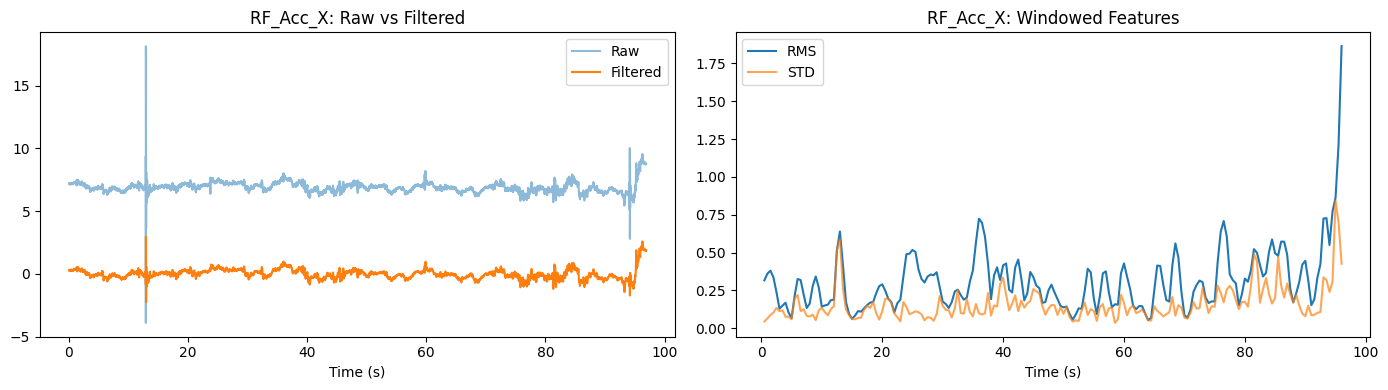

In [16]:
# ── Process one recording as sanity check ──
sample_rec = load_recording(recordings[0])
d_config = DASIGPreprocessConfig()

# Estimate actual sampling rate
dt = np.diff(sample_rec.mimu['Time_s'].values)
actual_fs = 1.0 / np.median(dt)
print(f'Sample: {sample_rec.info.recording_key}')
print(f'  Duration : {sample_rec.duration_s:.1f}s')
print(f'  Fs actual: {actual_fs:.1f} Hz')
print(f'  Alarms   : {sample_rec.n_alarms}')

# Preprocess
d_config_adj = DASIGPreprocessConfig(mimu_sampling_rate=actual_fs)
filtered = preprocess_mimu_dasig(sample_rec.mimu, d_config_adj)
features = extract_features_windowed(filtered, d_config_adj)
print(f'  Features : {features.shape}')

# Quick plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
t = sample_rec.mimu['Time_s'].values
axes[0].plot(t, sample_rec.mimu['RF_Acc_X'].values, alpha=0.5, label='Raw')
axes[0].plot(t, filtered['RF_Acc_X'].values, label='Filtered')
axes[0].set_title('RF_Acc_X: Raw vs Filtered')
axes[0].set_xlabel('Time (s)'); axes[0].legend()

axes[1].plot(features['t_center'], features['RF_Acc_X_rms'], label='RMS')
axes[1].plot(features['t_center'], features['RF_Acc_X_std'], label='STD', alpha=0.7)
axes[1].set_title('RF_Acc_X: Windowed Features')
axes[1].set_xlabel('Time (s)'); axes[1].legend()
plt.tight_layout(); plt.show()

In [17]:
# ── Run full DASIG pipeline ──
dasig_output = Path(f'{DATA_PROC}/dasig')
d_config = DASIGPreprocessConfig()

d_summary = {
    'n_recordings': len(recordings), 'processed': 0, 'failed': 0,
    'per_subject': {}
}
subject_features = {}  # for normalization

t0 = time.time()
for i, rec_info in enumerate(recordings):
    try:
        rec_data = load_recording(rec_info)

        if rec_data.mimu is None or rec_data.mimu.empty:
            d_summary['failed'] += 1; continue

        # Auto-detect sampling rate
        dt = np.diff(rec_data.mimu['Time_s'].values)
        fs = 1.0 / np.median(dt) if len(dt) > 0 else d_config.mimu_sampling_rate
        cfg = DASIGPreprocessConfig(mimu_sampling_rate=fs)

        # Filter
        filtered = preprocess_mimu_dasig(rec_data.mimu, cfg)

        # Segments (LA_L only)
        alarm_segs = []
        if rec_info.condition == 'LA_L' and rec_data.arduino is not None:
            alarm_segs = segment_around_alarms(filtered, rec_data.arduino, cfg)

        # Features
        features = extract_features_windowed(filtered, cfg)

        # Abrupt motions
        abrupt = detect_abrupt_motions(filtered, cfg)

        # Save
        rec_dir = dasig_output / rec_info.subject_id / rec_info.condition
        rec_dir.mkdir(parents=True, exist_ok=True)
        filtered.to_parquet(rec_dir / 'mimu_filtered.parquet', index=False)
        if not features.empty:
            features.to_parquet(rec_dir / 'features.parquet', index=False)
        if not abrupt.empty:
            abrupt.to_parquet(rec_dir / 'abrupt_events.parquet', index=False)
        for j, seg in enumerate(alarm_segs):
            seg_dir = rec_dir / 'alarm_segments'; seg_dir.mkdir(exist_ok=True)
            seg.to_parquet(seg_dir / f'segment_{j:03d}.parquet', index=False)

        meta = {'subject_id': rec_info.subject_id, 'condition': rec_info.condition,
                'n_features': len(features), 'n_alarm_segments': len(alarm_segs),
                'n_abrupt_events': len(abrupt), 'sampling_rate_hz': round(fs, 1)}
        with open(rec_dir / 'metadata.json', 'w') as f:
            json.dump(meta, f, indent=2)

        # Track features for normalization
        sid = rec_info.subject_id
        subject_features.setdefault(sid, []).append(features)

        d_summary['processed'] += 1
        if (i+1) % 30 == 0 or (i+1) == len(recordings):
            elapsed = time.time() - t0
            print(f'  [{i+1}/{len(recordings)}] {elapsed:.0f}s – '
                  f'{d_summary["processed"]} OK, {d_summary["failed"]} failed')

    except Exception as e:
        d_summary['failed'] += 1
        logger.error(f'{rec_info.recording_key}: {e}')

# Per-subject normalization
print('\nComputing per-subject normalization stats...')
for sid, feat_list in subject_features.items():
    stats = compute_subject_stats(feat_list)
    stats_path = dasig_output / sid / 'normalization_stats.json'
    with open(stats_path, 'w') as f:
        json.dump(stats, f, indent=2, default=str)

    for cond_dir in (dasig_output / sid).iterdir():
        if not cond_dir.is_dir() or cond_dir.name.startswith('.'): continue
        fp = cond_dir / 'features.parquet'
        if fp.exists():
            feat_df = pd.read_parquet(fp)
            norm = normalize_features(feat_df, stats, 'zscore')
            norm.to_parquet(cond_dir / 'features_normalized.parquet', index=False)

    d_summary['per_subject'][sid] = {
        'n_conditions': len(feat_list), 'n_feature_cols': len(stats)
    }

# Save subjects_info copy
if not info_df.empty:
    info_df.to_csv(dasig_output / 'subjects_info.csv', index=False)

elapsed = time.time() - t0
d_summary['elapsed_seconds'] = round(elapsed, 1)
with open(dasig_output / 'pipeline_summary.json', 'w') as f:
    json.dump(d_summary, f, indent=2)

print(f'\n{"="*60}')
print(f'DASIG Pipeline Complete')
print(f'{"="*60}')
print(f'  Processed : {d_summary["processed"]}/{len(recordings)}')
print(f'  Failed    : {d_summary["failed"]}')
print(f'  Subjects  : {len(subject_features)}')
print(f'  Time      : {elapsed:.1f}s')
print(f'  Output    : {dasig_output}')

  [30/180] 207s – 30 OK, 0 failed


/tmp/ipython-input-260901058.py:53: DtypeWarning: Columns (1,2,3,4,5,6,10,11,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(mimu_path, skiprows=3, sep=';', decimal=',', header=None)
ERROR:pipeline:sub013/LA_L: could not convert string to float: '4,265849'


  [60/180] 399s – 59 OK, 1 failed
  [90/180] 596s – 89 OK, 1 failed
  [120/180] 796s – 119 OK, 1 failed
  [150/180] 994s – 149 OK, 1 failed
  [180/180] 1197s – 179 OK, 1 failed

Computing per-subject normalization stats...

DASIG Pipeline Complete
  Processed : 179/180
  Failed    : 1
  Subjects  : 60
  Time      : 1270.6s
  Output    : /content/drive/MyDrive/thesis_project/data/processed/dasig


---
## 5. Train / Val / Test Splits

In [18]:
SEED = 42

# ── HARMONIC split (70/15/15 by participant) ──
harmonic_split = subject_stratified_split(
    participants, train_ratio=0.70, val_ratio=0.15, test_ratio=0.15, seed=SEED
)
save_split(harmonic_split, f'{SPLITS_DIR}/harmonic_split.json')

print('HARMONIC split:')
print(f'  Train : {len(harmonic_split["train"])} participants → {harmonic_split["train"]}')
print(f'  Val   : {len(harmonic_split["val"])}  participants → {harmonic_split["val"]}')
print(f'  Test  : {len(harmonic_split["test"])}  participants → {harmonic_split["test"]}')

# ── DASIG split (60/20/20 by subject, stratified by gender) ──
dasig_subjects = sorted(set(r.subject_id for r in recordings))

# Try gender stratification
strat_labels = None
if not info_df.empty:
    gender_col = None
    for col in info_df.columns:
        if any(g in col.lower() for g in ['gender', 'sex', 'genre']):
            gender_col = col; break
    if gender_col:
        id_col = info_df.columns[0]
        gender_map = dict(zip(info_df[id_col].astype(str), info_df[gender_col].astype(str)))
        strat_labels = [gender_map.get(sid, 'unknown') for sid in dasig_subjects]
        print(f'\nDASIG: stratifying by {gender_col}')

dasig_split = subject_stratified_split(
    dasig_subjects, train_ratio=0.60, val_ratio=0.20, test_ratio=0.20,
    seed=SEED, stratify_labels=strat_labels
)
save_split(dasig_split, f'{SPLITS_DIR}/dasig_split.json')

print(f'\nDASIG split:')
print(f'  Train : {len(dasig_split["train"])} subjects')
print(f'  Val   : {len(dasig_split["val"])} subjects')
print(f'  Test  : {len(dasig_split["test"])} subjects')

# ── Also generate LNSO folds for DASIG ──
lnso_folds = leave_n_subjects_out(dasig_subjects, n_out=5, seed=SEED)
save_split({'folds': lnso_folds}, f'{SPLITS_DIR}/dasig_lnso5_folds.json')
print(f'  LNSO-5 : {len(lnso_folds)} folds')

HARMONIC split:
  Train : 17 participants → ['p100', 'p101', 'p102', 'p103', 'p104', 'p105', 'p108', 'p109', 'p111', 'p112', 'p113', 'p115', 'p116', 'p117', 'p118', 'p121', 'p122']
  Val   : 4  participants → ['p107', 'p110', 'p120', 'p123']
  Test  : 3  participants → ['p106', 'p114', 'p119']

DASIG: stratifying by Gender

DASIG split:
  Train : 36 subjects
  Val   : 12 subjects
  Test  : 12 subjects
  LNSO-5 : 12 folds


---
## 6. Validation & Quality Report

In [19]:
# ── Verify output structure ──
print('HARMONIC processed output:')
h_parquets = list(Path(f'{DATA_PROC}/harmonic').rglob('*.parquet'))
h_metas    = list(Path(f'{DATA_PROC}/harmonic').rglob('metadata.json'))
print(f'  Parquet files : {len(h_parquets)}')
print(f'  Metadata files: {len(h_metas)}')

# Count per modality
from collections import Counter
h_mod_counts = Counter(p.stem for p in h_parquets)
print(f'  Per modality  :')
for mod, cnt in sorted(h_mod_counts.items(), key=lambda x: -x[1]):
    print(f'    {mod:25s} : {cnt}')

print(f'\nDASIG processed output:')
d_parquets = list(Path(f'{DATA_PROC}/dasig').rglob('*.parquet'))
d_metas    = list(Path(f'{DATA_PROC}/dasig').rglob('metadata.json'))
print(f'  Parquet files : {len(d_parquets)}')
print(f'  Metadata files: {len(d_metas)}')

d_mod_counts = Counter(p.stem for p in d_parquets)
print(f'  Per type      :')
for mod, cnt in sorted(d_mod_counts.items(), key=lambda x: -x[1]):
    print(f'    {mod:30s} : {cnt}')

# Splits
print(f'\nSplits directory:')
for f in sorted(Path(SPLITS_DIR).glob('*.json')):
    print(f'  {f.name}')

HARMONIC processed output:
  Parquet files : 2874
  Metadata files: 447
  Per modality  :
    ada_joy                   : 447
    gaze_positions            : 447
    joint_positions           : 447
    robot_position            : 447
    assistance_info           : 447
    input_info                : 447
    myo_emg                   : 96
    myo_imu                   : 96

DASIG processed output:
  Parquet files : 2781
  Metadata files: 179
  Per type      :
    mimu_filtered                  : 179
    features                       : 179
    abrupt_events                  : 179
    features_normalized            : 179
    segment_000                    : 59
    segment_001                    : 59
    segment_002                    : 59
    segment_003                    : 59
    segment_004                    : 59
    segment_005                    : 59
    segment_006                    : 59
    segment_007                    : 59
    segment_008                    : 59
    segment_

In [20]:
# ── Sample a few processed files to verify content ──
print('=== HARMONIC sample check ===')
sample_h = sorted(Path(f'{DATA_PROC}/harmonic').rglob('joint_positions.parquet'))[:3]
for p in sample_h:
    df = pd.read_parquet(p)
    print(f'  {p.parent.name}: {df.shape} — cols: {list(df.columns[:5])}...')

print(f'\n=== DASIG sample check ===')
sample_d = sorted(Path(f'{DATA_PROC}/dasig').rglob('features_normalized.parquet'))[:3]
for p in sample_d:
    df = pd.read_parquet(p)
    print(f'  {p.parent.name}: {df.shape}')
    # Check normalization: mean should be ~0, std ~1 for zscore
    feat_cols = [c for c in df.columns if not c.startswith('t_')]
    if feat_cols:
        means = df[feat_cols].mean().abs().mean()
        stds  = df[feat_cols].std().mean()
        print(f'    avg |mean| = {means:.4f}, avg std = {stds:.4f}')

=== HARMONIC sample check ===
  run_000: (3326, 25) — cols: ['time_s', 'mico_joint_1_pos', 'mico_joint_2_pos', 'mico_joint_3_pos', 'mico_joint_4_pos']...
  run_001: (2093, 25) — cols: ['time_s', 'mico_joint_1_pos', 'mico_joint_2_pos', 'mico_joint_3_pos', 'mico_joint_4_pos']...
  run_002: (1455, 25) — cols: ['time_s', 'mico_joint_1_pos', 'mico_joint_2_pos', 'mico_joint_3_pos', 'mico_joint_4_pos']...

=== DASIG sample check ===
  FR_L: (192, 497)
    avg |mean| = 0.2488, avg std = 0.8232
  FR_R: (192, 497)
    avg |mean| = 0.4680, avg std = 0.7883
  LA_L: (192, 497)
    avg |mean| = 0.2597, avg std = 0.7682


In [21]:
# ── Disk usage ──
import shutil

def dir_size_mb(path):
    total = sum(f.stat().st_size for f in Path(path).rglob('*') if f.is_file())
    return total / (1024 * 1024)

print('Disk Usage (processed data):')
print(f'  HARMONIC : {dir_size_mb(f"{DATA_PROC}/harmonic"):.1f} MB')
print(f'  DASIG    : {dir_size_mb(f"{DATA_PROC}/dasig"):.1f} MB')
print(f'  Total    : {dir_size_mb(DATA_PROC):.1f} MB')

Disk Usage (processed data):
  HARMONIC : 440.0 MB
  DASIG    : 3687.6 MB
  Total    : 4127.6 MB


---
## 7. Summary

### What was produced:

| Dataset | Output | Format | Location |
|---------|--------|--------|----------|
| HARMONIC | Aligned & filtered modalities | Parquet per modality per trial | `data/processed/harmonic/<pid>/run_<tid>/` |
| DASIG | Filtered MIMU + features + abrupt events | Parquet | `data/processed/dasig/<sid>/<condition>/` |
| DASIG | Normalized features | Parquet | `data/processed/dasig/<sid>/<condition>/features_normalized.parquet` |
| DASIG | Alarm segments (LA_L only) | Parquet | `data/processed/dasig/<sid>/LA_L/alarm_segments/` |
| Both | Train/Val/Test splits | JSON | `configs/splits/` |

### Next steps:
1. **Experiment 1** — Imitation Learning comparison (BC, DAgger, GAIL) using HARMONIC processed data
2. **Experiment 3** — Style modeling with DASIG features (PCA, clustering, style-conditioned generation)
3. **Experiment 2** — IRL comparison (MaxEnt, AIRL, T-REX)

All processed data is saved to Google Drive and persists across Colab sessions.